In [1]:
import pandas as pd

In [2]:
#import data
df = pd.read_csv('../data/telegram_data.csv')

In [3]:
df.columns

Index(['Channel Title', 'Channel Username', 'ID', 'Message', 'Date',
       'Media Path'],
      dtype='object')

In [4]:
df.head()

,Channel Title,Channel Username,ID,Message,Date,Media Path
0,Sheger online-store,@Shageronlinestore,7383,💥Miralux Hot plate\n ባለሁለት ምድጃ ስቶቭ\n\n 💯o...,2025-06-19 06:31:31+00:00,data/photos/@Shageronlinestore_7383.jpg
1,Sheger online-store,@Shageronlinestore,7382,💥7pcs glass water set\n\n✔️ አንድ ማራኪ ጆግና 6 መጠጫ ...,2025-06-18 11:19:11+00:00,data/photos/@Shageronlinestore_7382.jpg
2,Sheger online-store,@Shageronlinestore,7381,NaN,2025-06-18 11:19:11+00:00,data/photos/@Shageronlinestore_7381.jpg
3,Sheger online-store,@Shageronlinestore,7380,NaN,2025-06-18 11:19:11+00:00,data/photos/@Shageronlinestore_7380.jpg
4,Sheger online-store,@Shageronlinestore,7379,NaN,2025-06-18 11:19:11+00:00,data/photos/@Shageronlinestore_7379.jpg


In [5]:
df["Channel Title"].unique()

array(['Sheger online-store', 'ልዩ እቃ', 'SINA KIDS/ሲና ኪድስⓇ', 'ማራኪ ცЯﾑŋの™',
       'qnash.com - ቅናሽ ®️', 'ምርጥ ዕቃ'], dtype=object)

In [6]:
df["Message"].notnull().sum()



np.int64(20768)

In [7]:
df.shape

(35168, 6)

In [8]:
#drop rows with empty messages
df = df[df["Message"].notnull()]

In [9]:
first = df["Message"].head(1)
print(first)

0    💥Miralux Hot plate\n ባለሁለት ምድጃ ስቶቭ\n\n      💯o...
Name: Message, dtype: object


In [10]:
# remove new line from Message
df["Message"] = df["Message"].str.replace("\n", " ", regex=False)

In [11]:
# remove emojis and  special characters
df["Message"] = df["Message"].str.replace(r"[^\w\s]", "", regex=True)

In [12]:
# remove non Amharic characters and numbers
df["Message"] = df["Message"].str.replace(r"[^\u1200-\u137F\s0-9]", "", regex=True)

In [13]:
def normalize_amharic(text):
    # Unicode normalization map
    normalization_map = {
        "ሃ": "ሀ",
        "ሐ": "ሀ",
        "ኅ": "ሀ",
        "ኃ": "ሀ",
        "ሓ": "ሀ",
        "ኻ": "ሀ",
        "ሠ": "ሰ",
        "ሡ": "ሱ",
        "ሢ": "ሲ",
        "ሣ": "ሳ",
        "ሤ": "ሴ",
        "ሥ": "ስ",
        "ሦ": "ሶ",
        "ኸ": "ኀ",
        "ዓ": "አ",
        "ዐ": "አ",
        "ኰ": "ኮ",
        "ኲ": "ኩ",
        "ኺ": "ኀ",
        "ዅ": "ኀ",
        "ኍ": "ኀ",
        "ቸ": "ች",  # Often normalized in corpora
        "ጸ": "ፀ",  # Optional
    }

    for char, normalized_char in normalization_map.items():
        text = text.replace(char, normalized_char)

    # Optional: remove zero-width space and normalize whitespace
    text = text.replace("\u200c", "").replace("\u200b", "")
    text = ' '.join(text.split())  # Remove extra spaces
    return text


In [14]:
#Tokenize the messages
df["Message"] = df["Message"].str.split()


In [15]:
# drop rows if if there is no amharic text
df = df[df["Message"].apply(lambda x: any('\u1200' <= char <= '\u137F' for char in x))]

In [16]:
#save the cleaned data
df.to_csv('../data/telegram_data_cleaned.csv', index=False)

<Axes: xlabel='Channel Title'>

/home/sasa/Documents/code/KIAM/week4/venv/lib64/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Glyph 4635 (\N{ETHIOPIC SYLLABLE MAA}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/sasa/Documents/code/KIAM/week4/venv/lib64/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Glyph 4651 (\N{ETHIOPIC SYLLABLE RAA}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/sasa/Documents/code/KIAM/week4/venv/lib64/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Glyph 4778 (\N{ETHIOPIC SYLLABLE KI}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/sasa/Documents/code/KIAM/week4/venv/lib64/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Glyph 65425 (\N{HALFWIDTH KATAKANA LETTER MU}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/home/sasa/Documents/code/KIAM/week4/venv/lib64/python3.13/site-packages/IPython/core/events.py:82: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) mis

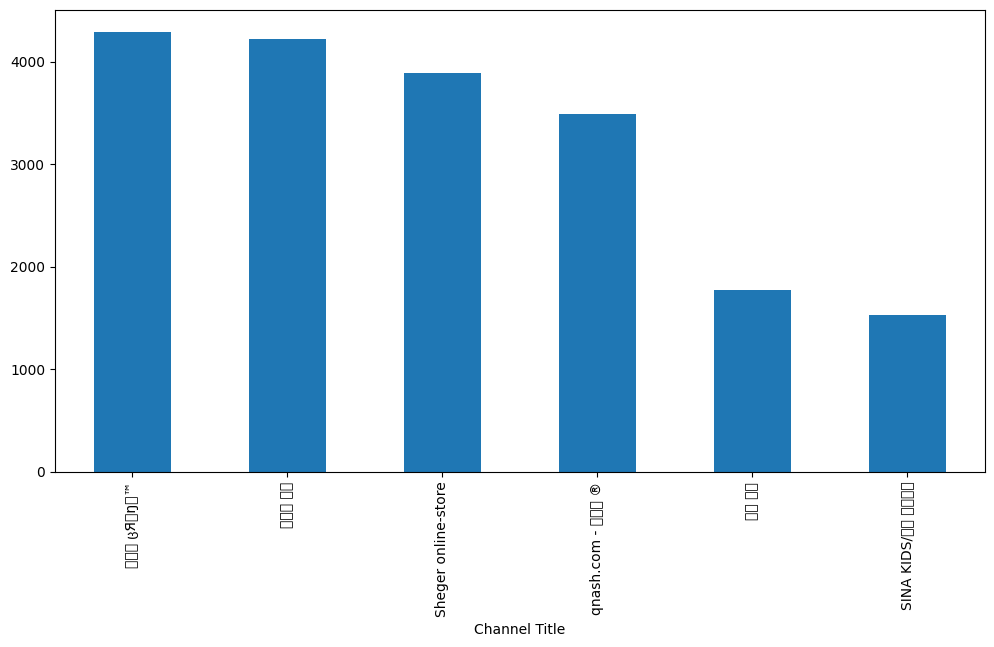

In [17]:
# Distribution of rows per channel
channel_counts = df["Channel Title"].value_counts()
#plotting the distribution
import matplotlib.pyplot as plt
channel_counts.plot(kind='bar', figsize=(12, 6))




In [18]:
# drop rows if if there is no amharic text
df = df[df["Message"].apply(lambda x: any('\u1200' <= char <= '\u137F' for char in x))]

In [19]:
df.shape

(19190, 6)